<a href="https://colab.research.google.com/github/emirmaciastec/MEM_M-todos_estadisticos/blob/main/lab2_4_nhanes_univariate_practice_Equipo9_HW2_21Sep25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IN4028 Métodos Estadísticos y Visualización

#### Doctor Carlos A. Díaz Tufinio
#### Maestra María Josefina Macías Rodríguez
#### Ingeniero Ramón Godina

##### María José Ayala Villanueva – A01797363
##### Emir Macías Sifuentes – A01797255
##### Juan Luis Nolazco Cervantes– A01797407
##### Soledad Arai Santiago Hernández - A01797345
##### Luciano Andrés Pilati - A01634098

# Homework Assignment 2 - Part 3

## Lab2 4 Nhanes_univariate_practice

In [3]:
import pandas as pd

# Read the data directly from the GitHub URL
url = "https://raw.githubusercontent.com/emirmaciastec/MEM_M-todos_estadisticos/main/nhanes_2015_2016.csv"
da = pd.read_csv(url)

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
import io



# Practice notebook for univariate analysis using NHANES data

This notebook will give you the opportunity to perform some univariate analyses on your own using the NHANES.  These analyses are similar to what was done in the week 2 NHANES case study notebook.

You can enter your code into the cells that say "enter your code here", and you can type responses to the questions into the cells that say "Type Markdown and Latex".

Note that most of the code that you will need to write below is very similar to code that appears in the case study notebook.  You will need to edit code from that notebook in small ways to adapt it to the prompts below.

To get started, we will use the same module imports and read the data in the same way as we did in the case study:

In [6]:
da.head ()

,SEQN,ALQ101,ALQ110,ALQ130,SMQ020,RIAGENDR,RIDAGEYR,RIDRETH1,DMDCITZN,DMDEDUC2,...,BPXSY2,BPXDI2,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,HIQ210
0,83732,1.0,NaN,1.0,1,1,62,3,1.0,5.0,...,124.0,64.0,94.8,184.5,27.8,43.3,43.6,35.9,101.1,2.0
1,83733,1.0,NaN,6.0,1,1,53,3,2.0,3.0,...,140.0,88.0,90.4,171.4,30.8,38.0,40.0,33.2,107.9,NaN
2,83734,1.0,NaN,NaN,1,1,78,3,1.0,3.0,...,132.0,44.0,83.4,170.1,28.8,35.6,37.0,31.0,116.5,2.0
3,83735,2.0,1.0,1.0,2,2,56,3,1.0,5.0,...,134.0,68.0,109.8,160.9,42.4,38.5,37.7,38.3,110.1,2.0
4,83736,2.0,1.0,1.0,2,2,42,4,1.0,4.0,...,114.0,54.0,55.2,164.9,20.3,37.4,36.0,27.2,80.4,2.0


## Question 1

Relabel the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to have brief but informative character labels.  Then construct a frequency table of these values for all people, then for women only, and for men only.  Then construct these three frequency tables using only people whose age is between 30 and 40.

In [ ]:
da.DMDMARTL.value_counts()

,count
DMDMARTL,
1.0,2780
5.0,1004
3.0,579
6.0,527
2.0,396
4.0,186
77.0,2


In [ ]:
da["MaritalStatus"] = da.DMDMARTL.replace({1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separeted", 5: "Never married", 6: "Living with partner",
                                       77: "Refused", 99: "Don't Know"}) #Relabel values in a new column
da.MaritalStatus.value_counts()

,count
MaritalStatus,
Married,2780
Never married,1004
Divorced,579
Living with partner,527
Widowed,396
Separeted,186
Refused,2


In [ ]:
da["Gender"] = da.RIAGENDR.replace({1: "Male", 2: "Female"}) #relabel values in new column

In [ ]:
da.groupby("Gender")["MaritalStatus"].value_counts() #Group by Gender and Marital Status

Gender  MaritalStatus      
Female  Married                1303
        Never married           520
        Divorced                350
        Widowed                 296
        Living with partner     262
        Separeted               118
        Refused                   1
Male    Married                1477
        Never married           484
        Living with partner     265
        Divorced                229
        Widowed                 100
        Separeted                68
        Refused                   1
Name: count, dtype: int64

In [ ]:
da["AgeGrp"] = pd.cut(da.RIDAGEYR, [30, 40,]) #Group only by 30,40

In [ ]:
da.groupby(["AgeGrp", "Gender"])["MaritalStatus"].value_counts()

/tmp/ipython-input-1407944057.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  da.groupby(["AgeGrp", "Gender"])["MaritalStatus"].value_counts()


AgeGrp    Gender  MaritalStatus      
(30, 40]  Female  Married                258
                  Never married           97
                  Living with partner     57
                  Divorced                43
                  Separeted               17
                  Widowed                  2
                  Refused                  0
          Male    Married                258
                  Never married           89
                  Living with partner     72
                  Divorced                24
                  Separeted               12
                  Widowed                  2
                  Refused                  1
Name: count, dtype: int64

__Q1a.__ Briefly comment on some of the differences that you observe between the distribution of marital status between women and men, for people of all ages.

__Q1b.__ Briefly comment on the differences that you observe between the distribution of marital status states for women between the overall population, and for women between the ages of 30 and 40.

__Q1c.__ Repeat part b for the men.

## Question 2

Restricting to the female population, stratify the subjects into age bands no wider than ten years, and construct the distribution of marital status within each age band.  Within each age band, present the distribution in terms of proportions that must sum to 1.

In [7]:
da["AgeGrp2"] = pd.cut(da.RIDAGEYR, [10,20,30,40,50,60,70,80,90]) #Group by 10 years

In [ ]:
dx = da.loc [~da.Gender.isin(["Male"]), :] #Remove Male Gender
dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places


MaritalStatus    Divorced  Living with partner  Married  Never married  Refused  Separeted  Widowed
AgeGrp2  Gender                                                                                    
(10, 20] Female     0.000                0.205    0.026          0.769    0.000      0.000    0.000
(20, 30] Female     0.021                0.206    0.305          0.446    0.000      0.021    0.000
(30, 40] Female     0.091                0.120    0.544          0.205    0.000      0.036    0.004
(40, 50] Female     0.137                0.074    0.574          0.125    0.000      0.066    0.024
(50, 60] Female     0.177                0.068    0.547          0.089    0.002      0.057    0.060
(60, 70] Female     0.193                0.043    0.481          0.086    0.000      0.050    0.147
(70, 80] Female     0.144                0.007    0.317          0.051    0.000      0.020    0.461
(80, 90] Female       NaN                  NaN      NaN            NaN      NaN        NaN      NaN


/tmp/ipython-input-1877259142.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status


__Q2a.__ Comment on the trends that you see in this series of marginal distributions.

__Q2b.__ Repeat the construction for males.

In [ ]:
dx = da.loc [~da.Gender.isin(["Female"]), :] #Remove Male Gender
dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

MaritalStatus    Divorced  Living with partner  Married  Never married  Refused  Separeted  Widowed
AgeGrp2  Gender                                                                                    
(10, 20] Male       0.000                0.075    0.025          0.900    0.000      0.000    0.000
(20, 30] Male       0.005                0.213    0.238          0.523    0.000      0.016    0.005
(30, 40] Male       0.052                0.157    0.563          0.194    0.002      0.026    0.004
(40, 50] Male       0.085                0.082    0.703          0.097    0.000      0.027    0.005
(50, 60] Male       0.126                0.075    0.652          0.104    0.000      0.022    0.022
(60, 70] Male       0.126                0.050    0.666          0.087    0.000      0.032    0.039
(70, 80] Male       0.142                0.022    0.612          0.022    0.000      0.035    0.167
(80, 90] Male         NaN                  NaN      NaN            NaN      NaN        NaN      NaN


/tmp/ipython-input-2804780163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status


__Q2c.__ Comment on any notable differences that you see when comparing these results for females and for males.

## Question 3

Construct a histogram of the distribution of heights using the BMXHT variable in the NHANES sample.

Text(0.5, 9.444444444444438, 'Height')

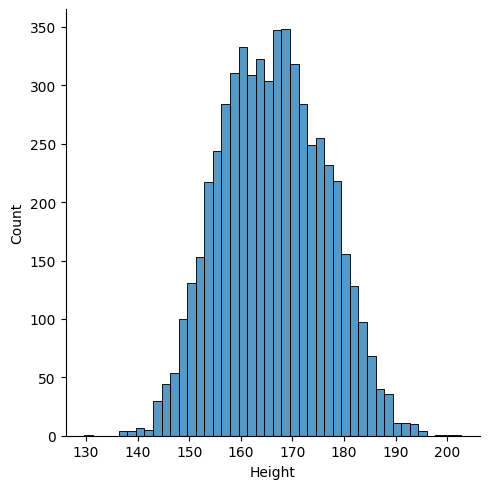

In [ ]:
sns.displot(da.BMXHT.dropna())
plt.xlabel("Height") #Change X label

__Q3a.__ Use the `bins` argument to [distplot](https://seaborn.pydata.org/generated/seaborn.distplot.html) to produce histograms with different numbers of bins.  Assess whether the default value for this argument gives a meaningful result, and comment on what happens as the number of bins grows excessively large or excessively small.

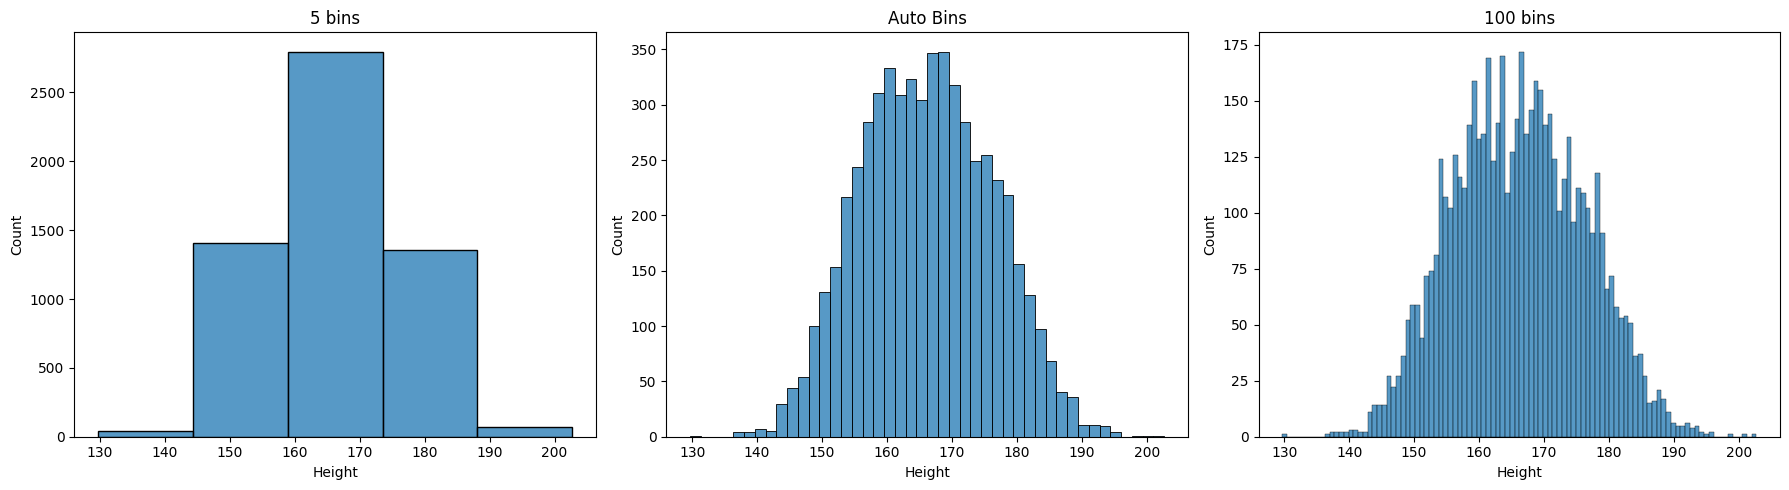

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #Show 3 tables

# 5 bins
sns.histplot(da["BMXHT"].dropna(), bins=5, ax=axes[0]) #Number of Bins
axes[0].set_title('5 bins') #Set Title

# Auto Bins
sns.histplot(da["BMXHT"].dropna(), ax=axes[1]) #Number of Bins
axes[1].set_title('Auto Bins') #Set Title

# 100 Bins
sns.histplot(da["BMXHT"].dropna(), bins=100, ax=axes[2]) #Number of Bins
axes[2].set_title('100 bins') #Set Title

for ax in axes:
    ax.set_xlabel("Height") #Change X label

plt.tight_layout()
plt.show()

__Q3b.__ Make separate histograms for the heights of women and men, then make a side-by-side boxplot showing the heights of women and men.

In [ ]:
Women = da[da['RIAGENDR'] == 2]['BMXHT'].dropna() # Filter Data by Women
Men = da[da['RIAGENDR'] == 1]['BMXHT'].dropna() # Filter Data by Men

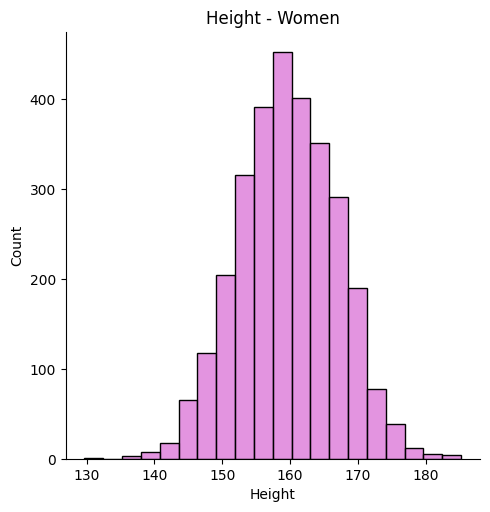

In [ ]:
sns.displot(Women, bins=20, color='orchid')
plt.title("Height - Women") #Set Title
plt.xlabel("Height") #Change X label
plt.show()

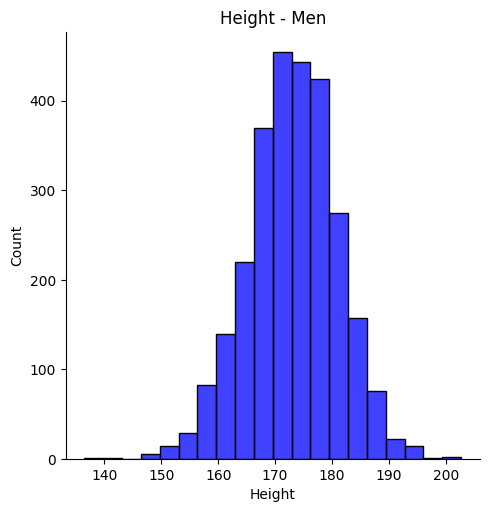

In [ ]:
sns.displot(Men, bins=20, color='blue')
plt.title("Height - Men") #Set Title
plt.xlabel("Height") #Change X label
plt.show()

Text(0, 0.5, 'Height')

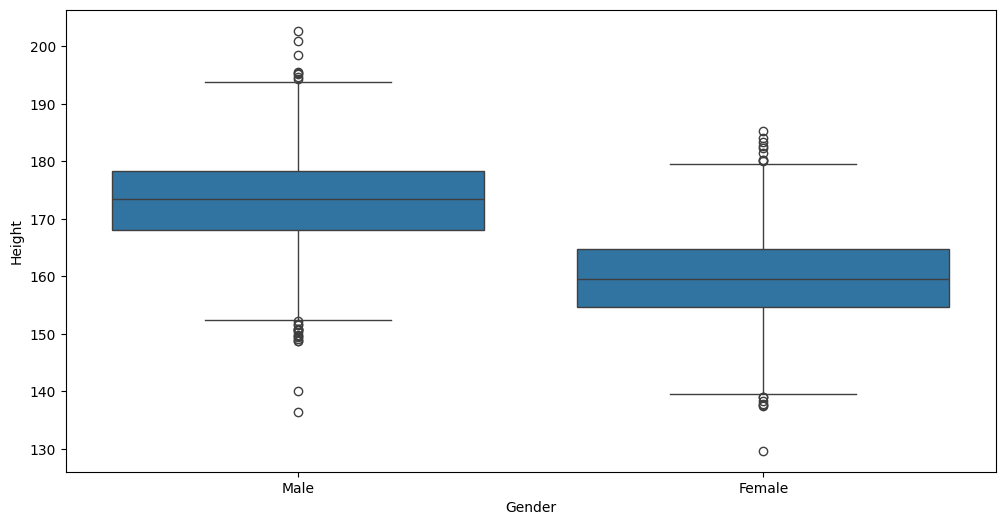

In [ ]:
plt.figure(figsize=(12, 6)) #Set Figure Size
sns.boxplot(x="Gender", y="BMXHT", data=da)
plt.ylabel ("Height") #Change Y label

<Axes: xlabel='Gender', ylabel='BMXHT'>

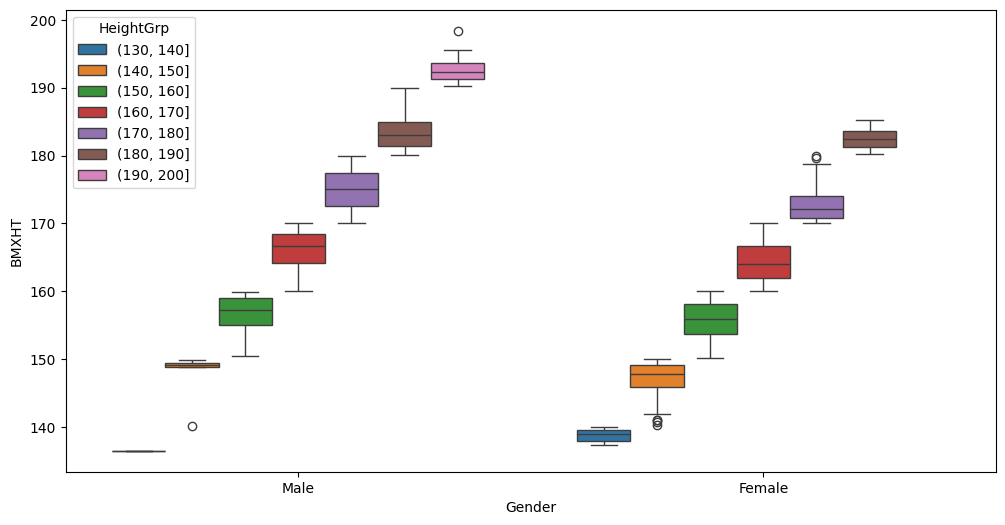

In [ ]:
da["HeightGrp"] = pd.cut(da.BMXHT, [130, 140, 150, 160, 170, 180, 190, 200]) #Group by height
plt.figure(figsize=(12, 6)) #Set figure size
sns.boxplot(x="Gender", y="BMXHT", hue="HeightGrp", data=da)

__Q3c.__ Comment on what features, if any are not represented clearly in the boxplots, and what features, if any, are easier to see in the boxplots than in the histograms.

## Question 4

Make a boxplot showing the distribution of within-subject differences between the first and second systolic blood pressure measurents ([BPXSY1](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY1) and [BPXSY2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY2)).

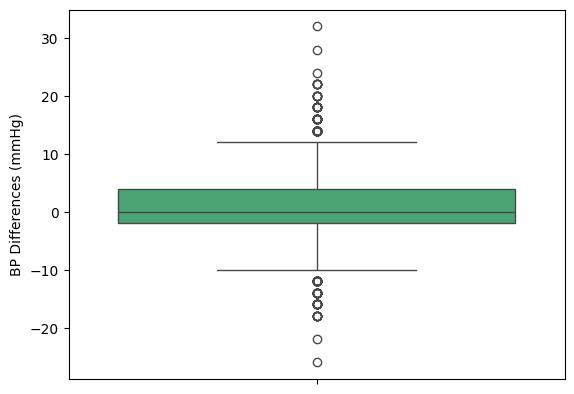

In [ ]:
da['BP_diff'] = da['BPXSY1'] - da['BPXSY2']
bp_diff = da['BP_diff'].dropna() # Delete null values
sns.boxplot(y=bp_diff, color='mediumseagreen')
plt.ylabel('BP Differences (mmHg)') #Change Y label
plt.show()

__Q4a.__ What proportion of the subjects have a lower SBP on the second reading compared to the first?

In [ ]:
bp_data = da[['BPXSY1', 'BPXSY2']].dropna() #Delete null values
lower_second = (bp_data['BPXSY2'] < bp_data['BPXSY1']).sum() #Sum of lower SBP on the second reading
proportion = lower_second / len(bp_data)
print(f"Proportion on the second reading: {proportion:.2%}")

Proportion on the second reading: 45.87%


/tmp/ipython-input-4120538258.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Comparison', data=bp_data, palette='Set2')


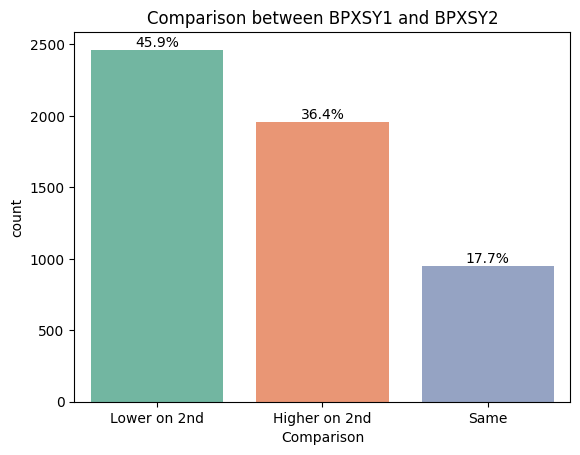

In [9]:
bp_data = da[['BPXSY1', 'BPXSY2']].dropna() #Delete null values
bp_data['Comparison'] = bp_data.apply(
    lambda row: 'Lower on 2nd' if row['BPXSY2'] < row['BPXSY1']
    else ('Higher on 2nd' if row['BPXSY2'] > row['BPXSY1'] else 'Same'), axis=1)

ax = sns.countplot(x='Comparison', data=bp_data, palette='Set2')
plt.title('Comparison between BPXSY1 and BPXSY2')

total = len(bp_data)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

__Q4b.__ Make side-by-side boxplots of the two systolic blood pressure variables.

Text(0, 0.5, 'Blood pressure in mm/Hg')

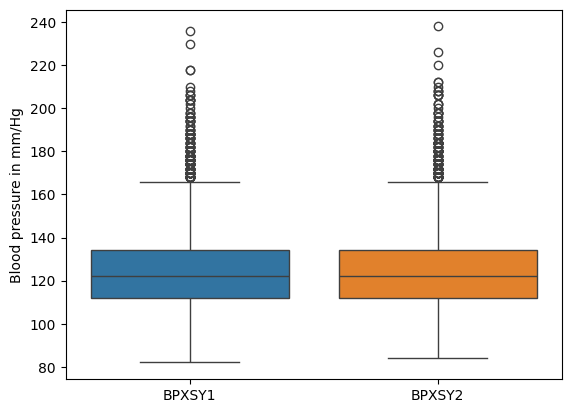

In [15]:
sns.boxplot(data=da.loc[:, ["BPXSY1", "BPXSY2"]])
plt.ylabel("Blood pressure in mm/Hg") #change Y label

__Q4c.__ Comment on the variation within either the first or second systolic blood pressure measurements, and the variation in the within-subject differences between the first and second systolic blood pressure measurements.

## Question 5

Construct a frequency table of household sizes for people within each educational attainment category (the relevant variable is [DMDEDUC2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDEDUC2)).  Convert the frequencies to proportions.

In [16]:
da['DMDHHSIZ'].value_counts().sort_index()

,count
DMDHHSIZ,
1,770
2,1546
3,1037
4,936
5,699
6,379
7,368


In [17]:
da.DMDEDUC2.value_counts()

,count
DMDEDUC2,
4.0,1621
5.0,1366
3.0,1186
1.0,655
2.0,643
9.0,3


In [18]:
da["Edulvl"] = da.DMDEDUC2.replace({1: "<9", 2: "9-11", 3: "HS/GED", 4: "Some college/AA", 5: "College",
                                       7: "Refused", 9: "Don't know"}) #Replace values
da.Edulvl.value_counts()

,count
Edulvl,
Some college/AA,1621
College,1366
HS/GED,1186
<9,655
9-11,643
Don't know,3


In [19]:
da.groupby(["DMDHHSIZ"])["Edulvl"].value_counts()

DMDHHSIZ  Edulvl         
1         Some college/AA    245
          College            195
          HS/GED             181
          9-11                75
          <9                  72
2         College            475
          Some college/AA    436
          HS/GED             321
          <9                 147
          9-11               143
          Don't know           2
3         Some college/AA    313
          College            265
          HS/GED             203
          9-11               105
          <9                  96
4         Some college/AA    274
          College            226
          HS/GED             192
          9-11                98
          <9                  87
5         Some college/AA    198
          College            130
          HS/GED             130
          <9                  97
          9-11                94
          Don't know           1
6         Some college/AA     82
          HS/GED              78
          9-11                73
          <9                  71
          College             40
7         <9                  85
          HS/GED              81
          Some college/AA     73
          9-11                55
          College             35
Name: count, dtype: int64

In [20]:
dx = da.groupby(["DMDHHSIZ"])["Edulvl"].value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

Edulvl    9-11    <9  College  Don't know  HS/GED  Some college/AA
DMDHHSIZ                                                          
1        0.098 0.094    0.254         NaN   0.236            0.319
2        0.094 0.096    0.312       0.001   0.211            0.286
3        0.107 0.098    0.270         NaN   0.207            0.319
4        0.112 0.099    0.258         NaN   0.219            0.312
5        0.145 0.149    0.200       0.002   0.200            0.305
6        0.212 0.206    0.116         NaN   0.227            0.238
7        0.167 0.258    0.106         NaN   0.246            0.222


:__Q5a.__ Comment on any major differences among the distributions.

__Q5b.__ Restrict the sample to people between 30 and 40 years of age.  Then calculate the median household size for women and men within each level of educational attainment.

In [ ]:
x = da[(da['RIDAGEYR'] >= 30) & (da['RIDAGEYR'] <= 40)] # Filter Years
x = x[['Gender', 'Edulvl', 'DMDHHSIZ']].dropna() # Extract all non-missing values
median = (x.groupby(['Gender', 'Edulvl'])['DMDHHSIZ'].median().unstack())
print (median)

Edulvl  9-11   <9  College  HS/GED  Some college/AA
Gender                                             
Female   5.0  5.0      3.0     5.0              4.0
Male     4.5  5.0      3.0     4.0              4.0


## Question 6

The participants can be clustered into "maked variance units" (MVU) based on every combination of the variables [SDMVSTRA](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVSTRA) and [SDMVPSU](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVPSU).  Calculate the mean age ([RIDAGEYR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIDAGEYR)), height ([BMXHT](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXHT)), and BMI ([BMXBMI](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXBMI)) for each gender ([RIAGENDR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIAGENDR)), within each MVU, and report the ratio between the largest and smallest mean (e.g. for height) across the MVUs.

In [ ]:
subset = da[['SDMVSTRA', 'SDMVPSU', 'Gender', 'RIDAGEYR', 'BMXHT', 'BMXBMI']].dropna() #Extract non-missin values

In [ ]:
mvu_means = (subset.groupby(['SDMVSTRA', 'SDMVPSU', 'Gender']).agg({'RIDAGEYR': 'mean','BMXHT': 'mean', 'BMXBMI': 'mean'}).reset_index()) #Calculate mean and group
print(mvu_means)

    SDMVSTRA  SDMVPSU  Gender   RIDAGEYR       BMXHT     BMXBMI
0        119        1  Female  47.663265  159.570408  30.052041
1        119        1    Male  47.861111  172.741667  26.958333
2        119        2  Female  52.987952  159.244578  27.849398
3        119        2    Male  54.162791  172.590698  27.160465
4        120        1  Female  43.887755  155.402041  32.419388
5        120        1    Male  43.030928  169.508247  30.939175
6        120        2  Female  43.736111  159.218056  27.400000
7        120        2    Male  45.219178  173.075342  27.727397
8        121        1  Female  44.252632  158.871579  30.856842
9        121        1    Male  46.427184  172.238835  29.416505
10       121        2  Female  44.376344  160.229032  26.470968
11       121        2    Male  42.279570  174.764516  26.273118
12       122        1  Female  42.897436  161.315385  29.447436
13       122        1    Male  44.896907  173.998969  28.528866
14       122        2  Female  47.333333

In [ ]:
ratio_age = mvu_means['RIDAGEYR'].max() / mvu_means['RIDAGEYR'].min()
ratio_height = mvu_means['BMXHT'].max() / mvu_means['BMXHT'].min()
ratio_bmi = mvu_means['BMXBMI'].max() / mvu_means['BMXBMI'].min()

print("Ratio between the largest and smallest mean across the MVUs.")
print(f"Age: {ratio_age:.2f}")
print(f"Height: {ratio_height:.2f}")
print(f"BMI: {ratio_bmi:.2f}")

Ratio between the largest and smallest mean across the MVUs.
Age: 1.32
Height: 1.14
BMI: 1.28


__Q6a.__ Comment on the extent to which mean age, height, and BMI vary among the MVUs.

__Q6b.__ Calculate the inter-quartile range (IQR) for age, height, and BMI for each gender and each MVU.  Report the ratio between the largest and smalles IQR across the MVUs.

In [ ]:
IQR_Table = (subset.groupby(['SDMVSTRA', 'SDMVPSU', 'Gender']).agg({'RIDAGEYR': lambda x: x.quantile(0.75) - x.quantile(0.25),'BMXHT': lambda x: x.quantile(0.75) - x.quantile(0.25),'BMXBMI': lambda x: x.quantile(0.75) - x.quantile(0.25)}).reset_index()) #Calculate ratio
print(IQR_Table)

    SDMVSTRA  SDMVPSU  Gender  RIDAGEYR   BMXHT  BMXBMI
0        119        1  Female     31.25   9.325   9.750
1        119        1    Male     29.75   9.000   5.350
2        119        2  Female     33.50   9.950   9.350
3        119        2    Male     30.00  11.150   5.300
4        120        1  Female     26.00   8.750   8.775
5        120        1    Male     24.00  12.200   9.400
6        120        2  Female     25.75  10.550   7.750
7        120        2    Male     26.00  10.500   7.100
8        121        1  Female     25.50   9.150   9.000
9        121        1    Male     34.50  10.550   7.500
10       121        2  Female     26.00   9.600   8.100
11       121        2    Male     26.00   8.600   5.700
12       122        1  Female     24.00  10.400   9.875
13       122        1    Male     29.00   9.400   7.700
14       122        2  Female     25.00   7.575   8.475
15       122        2    Male     30.00  10.150   4.100
16       123        1  Female     30.50   9.675 

In [ ]:
ratio_age_iqr = IQR_Table['RIDAGEYR'].max() / IQR_Table['RIDAGEYR'].min()
ratio_height_iqr = IQR_Table['BMXHT'].max() / IQR_Table['BMXHT'].min()
ratio_bmi_iqr = IQR_Table['BMXBMI'].max() / IQR_Table['BMXBMI'].min()

print("Ratio between the largest and smalles IQR across the MVUs")
print(f"Age: {ratio_age_iqr:.2f}")
print(f"Height: {ratio_height_iqr:.2f}")
print(f"BMI: {ratio_bmi_iqr:.2f}")

Ratio between the largest and smalles IQR across the MVUs
Age: 1.80
Height: 1.62
BMI: 2.87


__Q6c.__ Comment on the extent to which the IQR for age, height, and BMI vary among the MVUs.